# Étude du marché immobilier France / Île-de-France

Ce notebook exécute le même pipeline que le script Python principal, mais dans un format plus lisible.

**Ce que fait ce notebook :**

- charge et nettoie les données macro (France) et DVF (Île-de-France) ;
- construit des tableaux d’analyse (prix au m², revenus, loyers, taux, dette, etc.) ;
- génère les principaux graphiques utilisés dans la data visualisation et dans l’application Streamlit.

**Vue d’ensemble des étapes :**

1. **Données France** : prix, revenus, loyers, indices, taux d’intérêt, dette…
2. **Données DVF Île-de-France** : filtrage des appartements, nettoyage, calcul des prix au m² et volumes de ventes.
3. **DataFrames d’analyse** : France (longue période), IdF par département/commune, union Macro + DVF, focus “20 ans” et “5 ans”.
4. **Graphiques de synthèse** : pouvoir d’achat immobilier, indices prix/loyers, dette, prix par département, top communes, indicateurs d’accessibilité.

**Graphiques conservés dans ce notebook :**

- **G1** : variations annuelles prix / revenus / inflation (France)
- **G2** : indices prix logements France/Paris vs loyers
- **G3** : dette immobilière, durée des prêts, montants de transactions
- **G4** : prix médian au m² par département d’Île-de-France
- **G5** : top 10 communes les plus chères (IdF, prix médian au m²)
- **G6** : indicateurs d’accessibilité (prix/revenus, Paris/France, dette, prix/loyers)


## 1. Mise en place : librairies et paramètres

Cette cellule :

- importe les bibliothèques nécessaires (`numpy`, `pandas`, `matplotlib`, etc.) ;
- définit les chemins des fichiers d’entrée (macro, taux Banque de France, DVF) et le dossier `OUTPUT` ;
- fixe les paramètres globaux :
  - période d’analyse (années de début / fin) ;
  - liste des départements d’Île-de-France ;
  - options de lecture des fichiers DVF (séparateur, encodage, nom de colonne du département) ;
- définit les palettes de couleurs utilisées dans tous les graphiques.

👉 Si l’on change l’emplacement des données ou le périmètre géographique, c’est **ici** qu’il faut adapter les paramètres.



In [ ]:
# 1. IMPORTS & CONFIG
# ============================================================
import os
import glob
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# --- CONFIG A ADAPTER -------------------------------------------------
PATH_GLOBAL   = "INPUT/Dataprojetglobalhorsdvf.xlsx"
PATH_TAUX_BDF = "INPUT/tauxintérêtsBdFpour compléter années 2020-25.xlsx"
PATH_DVF_DIR  = "INPUT/DATADVF"  # Dossier avec les fichiers .txt DVF
OUTPUT_DIR    = ".\OUTPUT"

ANNEE_DEBUT      = 1990
ANNEE_FIN_MACRO  = 2025  # bornes macro France - étendu pour données récentes
DEPARTEMENTS_IDF = {"75", "77", "78", "91", "92", "93", "94", "95"}

# Mapping noms départements IdF
NOMS_DEPARTEMENTS = {
    "75": "Paris",
    "77": "Seine-et-Marne",
    "78": "Yvelines",
    "91": "Essonne",
    "92": "Hauts-de-Seine",
    "93": "Seine-Saint-Denis",
    "94": "Val-de-Marne",
    "95": "Val-d'Oise"
}

DVF_DELIMITER = "|"
DVF_ENCODING  = "utf-8"
DVF_CODE_DEPT_COL = "Code departement"

# Couleurs pour les graphiques
COLORS = {
    "france": "#1f77b4",
    "paris": "#d62728",
    "idf": "#2ca02c",
    "loyers": "#ff7f0e",
    "ipc": "#8c564b",
    "icc": "#e377c2",
    "taux": "#7f7f7f",
    "pib": "#bcbd22",
    "dette": "#17becf"
}

DEPT_COLORS = {
    "75": "#e41a1c",  # Paris - Rouge
    "92": "#377eb8",  # Hauts-de-Seine - Bleu
    "94": "#4daf4a",  # Val-de-Marne - Vert
    "93": "#984ea3",  # Seine-Saint-Denis - Violet
    "78": "#ff7f00",  # Yvelines - Orange
    "91": "#ffff33",  # Essonne - Jaune
    "95": "#a65628",  # Val-d'Oise - Marron
    "77": "#f781bf"   # Seine-et-Marne - Rose
}

<>:19: SyntaxWarning: invalid escape sequence '\O'
<>:19: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Bernard\AppData\Local\Temp\ipykernel_22532\2455391794.py:19: SyntaxWarning: invalid escape sequence '\O'
  OUTPUT_DIR    = ".\OUTPUT"


## 2. Boîte à outils (fonctions utilitaires)

Cette cellule regroupe des petites fonctions réutilisables dans tout le notebook :

- `afficher_section` : améliore la lisibilité des logs en console (grands séparateurs par partie) ;
- `afficher_df_info` et `afficher_resume_dataframe` : donnent un diagnostic rapide d’un DataFrame (taille, types, valeurs manquantes, aperçu) ;
- `exporter_dataframe` : enregistre un DataFrame en CSV de façon robuste ;
- fonctions de support DVF : collecte des fichiers texte, nettoyage / normalisation des codes département, conversion de colonnes en numérique.

En résumé, c’est la **boîte à outils technique** utilisée par les fonctions de chargement, de transformation et d’agrégation.



In [2]:
# 2. FONCTIONS UTILITAIRES
# ============================================================
def afficher_section(titre, niveau=1):
    """Affiche un titre de section formaté."""
    if niveau == 1:
        print("\n\n" + "=" * 100)
        print(f"  {titre}")
        print("=" * 100)
    else:
        print("\n" + "-" * 80)
        print(f"  {titre}")
        print("-" * 80)


def afficher_df_info(df: pd.DataFrame, nom_df: str):
    """Affiche les informations techniques d'un DataFrame."""
    print(f"\n  ┌─ {nom_df}.info()")
    print("  │")
    buffer = io.StringIO()
    df.info(buf=buffer)
    for line in buffer.getvalue().split("\n"):
        print(f"  │  {line}")
    print("  └" + "─" * 70)


def afficher_resume_dataframe(df: pd.DataFrame, nom_df: str = "DataFrame"):
    """Affiche un résumé complet d'un DataFrame."""
    print("=" * 80)
    print(f"RÉSUMÉ : {nom_df}")
    print("=" * 80)
    print(f"📊 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"💾 Mémoire   : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print("\nTYPES DE COLONNES")
    print("-" * 80)
    print(df.dtypes.to_string())

    print("\nVALEURS MANQUANTES")
    print("-" * 80)
    manquantes = df.isna().sum()
    manquantes = manquantes[manquantes > 0]
    if manquantes.empty:
        print("✅ Aucune valeur manquante")
    else:
        print(manquantes.to_string())

    print("\nAPERÇU (head)")
    print("-" * 80)
    print(df.head().to_string())

    print("\nAPERÇU (tail)")
    print("-" * 80)
    print(df.tail().to_string())


def exporter_dataframe(df: pd.DataFrame, nom_base: str, description: str = ""):
    """
    Exporte un DataFrame en CSV avec gestion des erreurs de permission.
    
    En cas d'erreur (fichier ouvert, Google Drive sync), essaie :
    1. D'ajouter un suffixe timestamp au nom
    2. D'exporter dans un dossier de fallback local
    """
    import time
    from datetime import datetime
    
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    path_csv = os.path.join(OUTPUT_DIR, f"{nom_base}.csv")
    print(f"\nEXPORT : {nom_base} – {description}")
    
    try:
        df.to_csv(path_csv, index=False, sep=";", encoding="utf-8-sig")
        print(f"  ✓ {path_csv}")
    except PermissionError:
        print(f"  ⚠ Permission refusée pour {path_csv}")
        print(f"    (Le fichier est peut-être ouvert dans Excel ou Google Drive synchronise)")
        
        # Tentative 1 : Ajouter un timestamp au nom
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        path_csv_ts = os.path.join(OUTPUT_DIR, f"{nom_base}_{timestamp}.csv")
        try:
            df.to_csv(path_csv_ts, index=False, sep=";", encoding="utf-8-sig")
            print(f"  ✓ Export alternatif : {path_csv_ts}")
            return
        except PermissionError:
            pass
        
        # Tentative 2 : Exporter dans le dossier utilisateur local
        fallback_dir = os.path.join(os.path.expanduser("~"), "Documents", "DATA_IMMO_EXPORT")
        os.makedirs(fallback_dir, exist_ok=True)
        path_csv_fallback = os.path.join(fallback_dir, f"{nom_base}.csv")
        try:
            df.to_csv(path_csv_fallback, index=False, sep=";", encoding="utf-8-sig")
            print(f"  ✓ Export fallback : {path_csv_fallback}")
        except Exception as e:
            print(f"  ✗ Échec de l'export : {e}")
            print(f"    → Fermez le fichier {nom_base}.csv et relancez le script")


def collect_txt_files_dvf(input_path: str):
    """Collecte les fichiers .txt DVF dans un répertoire."""
    if os.path.isdir(input_path):
        return glob.glob(os.path.join(input_path, "*.txt"))
    elif os.path.isfile(input_path) and input_path.lower().endswith(".txt"):
        return [input_path]
    return []


def normalize_code_departement(code):
    """Normalise un code département (supprime zéros initiaux, gère Corse)."""
    if code is None or (isinstance(code, float) and np.isnan(code)):
        return ""
    s = str(code).strip().upper()
    if not s:
        return s
    if s.isdigit():
        return s.lstrip("0") or "0"
    return s


def trouver_colonne(df: pd.DataFrame, candidats):
    """Trouve une colonne parmi plusieurs noms possibles."""
    for c in candidats:
        if c in df.columns:
            return c
    raise KeyError(f"Aucune des colonnes {candidats} trouvée dans le DataFrame")


def nettoyer_colonne_num(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Nettoie et convertit une colonne en numérique."""
    df[col] = (
        df[col].astype(str)
        .str.replace("\xa0", "")
        .str.replace(" ", "")
        .str.replace(",", ".")
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

## 3. Chargement et préparation des données

Cette cellule contient le cœur du pipeline de données :

- `charger_taux_bdf` :
  - lit le fichier Excel des taux d’intérêt Banque de France ;
  - nettoie les en-têtes et calcule un taux moyen par année.
- `charger_macro` :
  - lit le fichier macro global (prix, revenus, loyers, dette, PIB, etc.) ;
  - renomme les colonnes de manière explicite ;
  - convertit les colonnes en numérique et filtre la période étudiée.
- `charger_dvf_idf` :
  - parcourt les fichiers DVF d’un répertoire ;
  - ne garde que les ventes d’Île-de-France.
- `filtrer_dvf_appartements` :
  - isole les ventes d’appartements et prépare les variables clés (surface, prix au m², etc.).
- `construire_macro_analyse` :
  - enrichit les données France avec des indices et ratios (prix/revenus, prix/loyers, Paris/France, dette/revenus…) ;
  - prépare deux vues : une série longue et un focus sur ~20 ans ;
- `construire_dvf_agregats` :
  - agrège les DVF par année, département, commune ;
  - calcule prix médians/moyens, volumes de transactions, et filtre les outliers ;
- `construire_df_union_macro_dvf` :
  - met bout à bout les blocs Macro et DVF pour avoir une vue unifiée France / Île-de-France ;
- `construire_df_global_5` :
  - construit un tableau simplifié France vs IdF sur les 5 dernières années (pour comparer prix et revenus).

C’est en pratique la **partie préparation des données** : tout ce qui sert à passer des fichiers bruts aux indicateurs utilisés dans les graphiques.


In [3]:
# 3. FONCTIONS DE CHARGEMENT / TRANSFORMATION
# ============================================================
def charger_taux_bdf(path_taux: str) -> pd.DataFrame:
    """Charge et agrège les taux d'intérêt Banque de France."""
    afficher_section("A.1 – Taux d'intérêt Banque de France", niveau=2)
    df_taux_raw = pd.read_excel(path_taux)
    afficher_df_info(df_taux_raw, "df_taux_raw (BRUT)")

    df_taux_raw.columns = ["Date", "Taux_Pourcent", "Taux_Decimal"]
    df = df_taux_raw.iloc[5:].copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Taux_Decimal"] = pd.to_numeric(df["Taux_Decimal"], errors="coerce")
    df = df.dropna(subset=["Taux_Decimal"])
    df["Année"] = df["Date"].dt.year.astype("Int64")

    afficher_df_info(df, "df_taux (NETTOYÉ)")
    afficher_resume_dataframe(df, "df_taux (NETTOYÉ)")

    df_annuel = (
        df.groupby("Année")
        .agg(TauxMoyen=("Taux_Decimal", "mean"))
        .round(6)
        .reset_index()
    )
    afficher_df_info(df_annuel, "df_taux_annuel")
    print("\nAPERÇU df_taux_annuel :")
    print(df_annuel.head(10).to_string())

    exporter_dataframe(df_annuel, "01_Taux_Interet_BdF_Annuel", "Taux moyens annuels BdF")
    return df_annuel


def charger_macro(path_global: str, df_taux_annuel: pd.DataFrame) -> pd.DataFrame:
    """Charge et nettoie les données macroéconomiques France."""
    afficher_section("A.2 – Données macroéconomiques France", niveau=2)

    df_raw = pd.read_excel(path_global, header=1)
    afficher_df_info(df_raw, "df_macro_raw (BRUT)")
    df_raw = df_raw.iloc[2:].copy()

    # mapping colonnes => les indices suivent ton fichier d'origine
    colonnes_macro = {
        df_raw.columns[0]: "Année",
        df_raw.columns[1]: "IPC_base2000",
        df_raw.columns[2]: "PIB_MdEUR",
        df_raw.columns[3]: "RevenuDispoMenages_MdEUR",
        df_raw.columns[4]: "Population_milliers",
        df_raw.columns[5]: "NbMenages_milliers",
        df_raw.columns[6]: "TauxInteretLongTerme",
        df_raw.columns[7]: "TauxInteretCourtTerme",
        df_raw.columns[8]: "PrixOr_base2000",
        df_raw.columns[9]: "IndPrixLogements_France_base2000",
        df_raw.columns[10]: "IndPrixLogements_Paris_base2000",
        df_raw.columns[11]: "ValeurInvestLogLocatif_Paris_base2000",
        df_raw.columns[12]: "IndiceLoyers_base2000",
        df_raw.columns[13]: "ICC_base2000",
        df_raw.columns[14]: "ConsoMenages_Logement_MdEUR",
        df_raw.columns[15]: "MontantTransacImmo_Total_MdEUR",
        df_raw.columns[16]: "MontantTransacLogementsAnciens_MdEUR",
        df_raw.columns[17]: "NbTransacLogementsAnciens",
        df_raw.columns[18]: "NbLogementsCommences",
        df_raw.columns[19]: "DetteImmoMenages_MdEUR",
        df_raw.columns[20]: "DureePrets_annees",
    }
    df_raw.rename(columns=colonnes_macro, inplace=True)

    # suppression de colonnes
    colonnes_a_supprimer = [
        "Population_milliers",
        "TauxInteretCourtTerme",
        "MontantTransacImmo_Total_MdEUR",
        "NbLogementsCommences",
        "ValeurInvestLogLocatif_Paris_base2000",
        "PrixOr_base2000",
    ]
    df = df_raw.drop(columns=colonnes_a_supprimer, errors="ignore")

    # types numériques
    df["Année"] = pd.to_numeric(df["Année"], errors="coerce").astype("Int64")
    for c in df.columns:
        if c != "Année":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["Année"])
    df = df[
        (df["Année"] >= ANNEE_DEBUT) & (df["Année"] <= ANNEE_FIN_MACRO)
    ].copy()
    df["Region"] = "France"

    # complétion taux LT à partir de BdF si dispo
    if "TauxInteretLongTerme" in df.columns:
        for annee in range(2021, 2026):
            taux_bdf = df_taux_annuel.loc[df_taux_annuel["Année"] == annee, "TauxMoyen"]
            if not taux_bdf.empty:
                mask = df["Année"] == annee
                if mask.any():
                    df.loc[mask, "TauxInteretLongTerme"] = taux_bdf.iloc[0]

    df = df.sort_values("Année").reset_index(drop=True)

    afficher_df_info(df, "df_macro (NETTOYÉ)")
    afficher_resume_dataframe(df, "df_macro (NETTOYÉ)")

    exporter_dataframe(
        df, "02_DF_Macro_National",
        "Données macro France (1990–2020, colonnes nettoyées)"
    )
    return df


def charger_dvf_idf(path_dir: str) -> pd.DataFrame:
    """Charge les données DVF brutes pour l'Île-de-France."""
    afficher_section("B.1 – Chargement DVF (Île-de-France)", niveau=2)
    txt_files = collect_txt_files_dvf(path_dir)

    if not txt_files:
        print(f"  ⚠ Aucun fichier .txt trouvé dans {path_dir}")
        return pd.DataFrame()

    print(f"  {len(txt_files)} fichier(s) DVF trouvé(s)")
    dfs = []
    for path in txt_files:
        print(f"  Lecture : {os.path.basename(path)}")
        try:
            df_tmp = pd.read_csv(path, sep=DVF_DELIMITER, dtype=str, encoding=DVF_ENCODING)
        except UnicodeDecodeError:
            print(f"    ⚠ Encodage KO pour {path}, fichier ignoré")
            continue

        if DVF_CODE_DEPT_COL not in df_tmp.columns:
            print(f"    ⚠ Colonne '{DVF_CODE_DEPT_COL}' absente, fichier ignoré")
            continue

        df_tmp["CodeDeptNorm"] = df_tmp[DVF_CODE_DEPT_COL].apply(normalize_code_departement)
        n_avant = df_tmp.shape[0]
        df_tmp = df_tmp[df_tmp["CodeDeptNorm"].isin(DEPARTEMENTS_IDF)]
        n_apres = df_tmp.shape[0]
        print(f"    {n_apres}/{n_avant} lignes conservées (départements IdF)")

        dfs.append(df_tmp)

    if not dfs:
        print("  ⚠ Aucun enregistrement IdF")
        return pd.DataFrame()

    df_dvf_brut = pd.concat(dfs, ignore_index=True)
    df_dvf_brut.columns = [c.strip() for c in df_dvf_brut.columns]

    afficher_df_info(df_dvf_brut, "df_dvf_brut (IdF BRUT)")
    afficher_resume_dataframe(df_dvf_brut, "df_dvf_brut (IdF BRUT)")
    return df_dvf_brut


def filtrer_dvf_appartements(df_dvf_brut: pd.DataFrame) -> pd.DataFrame:
    """Filtre les données DVF pour ne conserver que les ventes d'appartements."""
    afficher_section("B.2 – Filtre DVF : Ventes d'appartements IdF", niveau=2)
    if df_dvf_brut.empty:
        print("  ⚠ df_dvf_brut vide")
        return pd.DataFrame()

    df = df_dvf_brut.copy()
    col_nature = trouver_colonne(df, ["Nature mutation", "Nature de mutation"])
    col_type   = trouver_colonne(df, ["Type local"])
    col_date   = trouver_colonne(df, ["Date mutation", "Date de mutation"])

    m_vente = df[col_nature].astype(str).str.strip().str.upper() == "VENTE"
    m_app   = df[col_type].astype(str).str.strip().str.upper() == "APPARTEMENT"
    df = df[m_vente & m_app].copy()

    df["Region"] = "Ile de France"
    df[col_date] = pd.to_datetime(df[col_date], errors="coerce", dayfirst=True)
    df["Année"]  = df[col_date].dt.year.astype("Int64")
    df = df.dropna(subset=["Année"])

    colonnes_a_supprimer = [
        "Identifiant de document", "Reference document",
        "1 Articles CGI", "2 Articles CGI", "3 Articles CGI",
        "4 Articles CGI", "5 Articles CGI",
        "No disposition", "Prefixe de section", "Section", "No plan",
        "No Volume",
        "1er lot", "Surface Carrez du 1er lot",
        "2eme lot", "Surface Carrez du 2eme lot",
        "3eme lot", "Surface Carrez du 3eme lot",
        "4eme lot", "Surface Carrez du 4eme lot",
        "5eme lot", "Surface Carrez du 5eme lot",
        "Nombre de lots", "Code type local", "Type local",
        "Identifiant local", "Nombre pieces principales",
        "Nature culture", "Nature culture speciale", "Surface terrain",
        "B/T/Q",
    ]
    df = df.drop(columns=[c.strip() for c in colonnes_a_supprimer], errors="ignore")

    afficher_df_info(df, "df_dvf_idf (VENTES APPARTEMENTS)")
    afficher_resume_dataframe(df, "df_dvf_idf (VENTES APPARTEMENTS)")

    exporter_dataframe(
        df, "03_DVF_IDF_Appartements_Ventes",
        "DVF IdF – ventes d'appartements (colonnes nettoyées)"
    )
    return df


def construire_macro_analyse(df_macro: pd.DataFrame):
    """Construit les DataFrames d'analyse macro avec indices calculés et enrichis."""
    afficher_section("C.1 – Préparation macro (France) avec indicateurs enrichis", niveau=2)
    df = df_macro.copy()

    # --- Indicateurs de revenu ---
    df["RevenuMoyen_kEUR_par_menage"] = (
        df["RevenuDispoMenages_MdEUR"] * 1_000 / df["NbMenages_milliers"]
    )

    # Indice revenu base 2000
    base_rev = df.loc[df["Année"] == 2000, "RevenuMoyen_kEUR_par_menage"]
    if not base_rev.empty:
        ref = base_rev.iloc[0]
        df["Indice_RevenuMoyen_base1"] = df["RevenuMoyen_kEUR_par_menage"] / ref
        df["Indice_RevenuMoyen_base2000"] = df["Indice_RevenuMoyen_base1"] * 100
    else:
        df["Indice_RevenuMoyen_base1"] = np.nan
        df["Indice_RevenuMoyen_base2000"] = np.nan

    # --- Nouveaux indices base 2000 ---
    # Indice PIB base 2000
    base_pib = df.loc[df["Année"] == 2000, "PIB_MdEUR"]
    if not base_pib.empty:
        ref_pib = base_pib.iloc[0]
        df["Indice_PIB_base2000"] = df["PIB_MdEUR"] / ref_pib * 100
    else:
        df["Indice_PIB_base2000"] = np.nan

    # Indice Taux LT base 2000
    base_taux = df.loc[df["Année"] == 2000, "TauxInteretLongTerme"]
    if not base_taux.empty and base_taux.iloc[0] != 0:
        ref_taux = base_taux.iloc[0]
        df["Indice_TauxLT_base2000"] = df["TauxInteretLongTerme"] / ref_taux * 100
    else:
        df["Indice_TauxLT_base2000"] = np.nan

    # Indice Dette Immo base 2000
    base_dette = df.loc[df["Année"] == 2000, "DetteImmoMenages_MdEUR"]
    if not base_dette.empty and pd.notnull(base_dette.iloc[0]) and base_dette.iloc[0] != 0:
        ref_dette = base_dette.iloc[0]
        df["Indice_DetteImmo_base2000"] = df["DetteImmoMenages_MdEUR"] / ref_dette * 100
    else:
        df["Indice_DetteImmo_base2000"] = np.nan

    # Indice Transactions anciens base 2000
    base_transac = df.loc[df["Année"] == 2000, "MontantTransacLogementsAnciens_MdEUR"]
    if not base_transac.empty and pd.notnull(base_transac.iloc[0]) and base_transac.iloc[0] != 0:
        ref_transac = base_transac.iloc[0]
        df["Indice_TransacAnciens_base2000"] = df["MontantTransacLogementsAnciens_MdEUR"] / ref_transac * 100
    else:
        df["Indice_TransacAnciens_base2000"] = np.nan

    # --- Ratios d'accessibilité immobilière ---
    # Ratio Prix logements / Revenu (effort d'achat)
    # Utiliser Indice_RevenuMoyen_base1 pour cohérence avec IndPrixLogements
    # (les deux doivent être dans la même base pour un ratio pertinent)
    if "IndPrixLogements_France_base2000" in df.columns and "Indice_RevenuMoyen_base1" in df.columns:
        df["Ratio_PrixLog_Revenu"] = (
            df["IndPrixLogements_France_base2000"] / df["Indice_RevenuMoyen_base1"]
        )

    # Ratio Prix logements Paris / France (écart Paris)
    if "IndPrixLogements_Paris_base2000" in df.columns and "IndPrixLogements_France_base2000" in df.columns:
        df["Ratio_Paris_France"] = (
            df["IndPrixLogements_Paris_base2000"] / df["IndPrixLogements_France_base2000"]
        )

    # Ratio Prix / Loyers (inverse du rendement locatif)
    if "IndiceLoyers_base2000" in df.columns and "IndPrixLogements_France_base2000" in df.columns:
        df["Ratio_Prix_Loyers"] = (
            df["IndPrixLogements_France_base2000"] / df["IndiceLoyers_base2000"]
        )

    # Dette immo par ménage (en k€)
    df["DetteImmo_kEUR_par_menage"] = (
        df["DetteImmoMenages_MdEUR"] * 1_000 / df["NbMenages_milliers"]
    )

    # Taux d'endettement immo / revenu
    df["Taux_Endettement_Immo"] = (
        df["DetteImmo_kEUR_par_menage"] / df["RevenuMoyen_kEUR_par_menage"]
    )

    # --- Évolutions annuelles (%) ---
    df["Evol_PrixLog_France_pct"] = df["IndPrixLogements_France_base2000"].pct_change() * 100
    df["Evol_Revenu_pct"] = df["RevenuMoyen_kEUR_par_menage"].pct_change() * 100
    df["Evol_Dette_pct"] = df["DetteImmoMenages_MdEUR"].pct_change() * 100

    df = df.sort_values("Année").reset_index(drop=True)

    # DataFrame sur ~20 ans (au lieu de 30)
    annee_max = int(df["Année"].max())
    annee_min_20 = annee_max - 19
    df_20 = df[df["Année"] >= annee_min_20].copy()

    print(f"\n  ✓ {len(df)} années de données macro")
    print(f"  ✓ Focus 20 ans : {annee_min_20} – {annee_max}")
    print(f"  ✓ Nouveaux indicateurs créés : {len([c for c in df.columns if 'Indice_' in c or 'Ratio_' in c or 'Evol_' in c])}")

    afficher_resume_dataframe(df, "df_macro_analyse (France)")
    afficher_resume_dataframe(df_20, "df_macro_20 (France, ~20 ans)")
    return df, df_20

def construire_dvf_agregats(df_dvf_idf: pd.DataFrame):
    """
    Construit les agrégats DVF par année, département et commune avec Top 10.
    Ajout du filtrage des outliers sur Prix_m2 via méthode IQR
    pour éliminer les transactions aberrantes (erreurs de saisie, biens atypiques).
    """
    afficher_section("C.2 – Préparation DVF Île-de-France", niveau=2)

    if df_dvf_idf.empty:
        print("  ⚠ Pas de DVF IdF, pas d'agrégats")
        return (
            pd.DataFrame(), pd.DataFrame(), pd.DataFrame(),
            pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        )

    df = df_dvf_idf.copy()

    col_valeur = trouver_colonne(df, ["Valeur fonciere", "Valeur foncière"])
    col_surf   = trouver_colonne(df, ["Surface reelle bati", "Surface réelle bâti"])

    df = nettoyer_colonne_num(df, col_valeur)
    df = nettoyer_colonne_num(df, col_surf)
    df.rename(
        columns={col_valeur: "ValeurFonciere_EUR", col_surf: "Surface_Bati_m2"},
        inplace=True,
    )

    # Calcul du prix au m²
    df["Prix_m2"] = df["ValeurFonciere_EUR"] / df["Surface_Bati_m2"].replace({0: np.nan})
    print("\n  📊 Filtrage des outliers sur Prix_m2...")
    
    # Supprimer les valeurs nulles ou négatives
    df = df[df["Prix_m2"].notna() & (df["Prix_m2"] > 0)].copy()
    n_avant_filtre = len(df)
    
    # Méthode IQR (InterQuartile Range) pour filtrer les outliers
    Q1 = df["Prix_m2"].quantile(0.01)  # 1er percentile
    Q3 = df["Prix_m2"].quantile(0.99)  # 99ème percentile
    IQR = Q3 - Q1
    
    # Bornes de filtrage réalistes pour l'Île-de-France
    borne_inf = max(500, Q1 - 1.5 * IQR)    # Minimum 500 €/m²
    borne_sup = min(25000, Q3 + 1.5 * IQR)  # Maximum 25 000 €/m²
    
    df = df[(df["Prix_m2"] >= borne_inf) & (df["Prix_m2"] <= borne_sup)].copy()
    n_apres_filtre = len(df)
    
    print(f"    • Bornes de filtrage : {borne_inf:,.0f} €/m² - {borne_sup:,.0f} €/m²")
    print(f"    • Transactions avant filtre : {n_avant_filtre:,}")
    print(f"    • Transactions après filtre : {n_apres_filtre:,}")
    print(f"    • Outliers supprimés : {n_avant_filtre - n_apres_filtre:,} ({(n_avant_filtre - n_apres_filtre) / n_avant_filtre * 100:.2f}%)")
  
    # Ajouter nom département
    df["NomDepartement"] = df["CodeDeptNorm"].map(NOMS_DEPARTEMENTS)

    afficher_resume_dataframe(df, "df_dvf_analyse (IdF – lignes filtrées)")

    # --- Agrégats IdF global par année ---
    df_agg_idf = (
        df.groupby("Année")
        .agg(
            Nb_ventes=("Prix_m2", "count"),
            Prix_m2_moyen=("Prix_m2", "mean"),
            Prix_m2_median=("Prix_m2", "median"),
            # Prix_m2_std supprimé car jamais exploité dans les analyses/graphes
        )
        .reset_index()
    )
    df_agg_idf["Region"] = "Ile de France"

    annee_max = int(df_agg_idf["Année"].max())
    annee_min_5 = annee_max - 4
    df_agg_5 = df_agg_idf[df_agg_idf["Année"] >= annee_min_5].copy()
    print("\nAGRÉGATS IdF (5 dernières années) :")
    print(df_agg_5.to_string(index=False))

    # --- Agrégats par département (≈10 ans) ---
    if "CodeDeptNorm" in df.columns:
        df_dept = (
            df.groupby(["Année", "CodeDeptNorm", "NomDepartement"])
            .agg(
                Nb_ventes=("Prix_m2", "count"),
                Prix_m2_moyen=("Prix_m2", "mean"),
                Prix_m2_median=("Prix_m2", "median"),
                # Prix_m2_std supprimé pour la même raison
            )
            .reset_index()
        )

        annee_max_dept = int(df_dept["Année"].max())
        annee_min_dept_10 = annee_max_dept - 9
        df_dept_10 = df_dept[df_dept["Année"] >= annee_min_dept_10].copy()
        
        # Affichage des prix par département pour vérification
        print(f"\n  VÉRIFICATION : Prix m² par département ({annee_max_dept}) :")
        df_verif = df_dept[df_dept["Année"] == annee_max_dept][["CodeDeptNorm", "NomDepartement", "Prix_m2_moyen", "Prix_m2_median", "Nb_ventes"]]
        df_verif = df_verif.sort_values("Prix_m2_moyen", ascending=False)
        print(df_verif.to_string(index=False))
    else:
        df_dept_10 = pd.DataFrame()
        df_dept    = pd.DataFrame()

    # Dernière année par département
    if not df_dept.empty:
        annee_max_all = int(df_dept["Année"].max())
        df_dept_last = df_dept[df_dept["Année"] == annee_max_all].copy()
    else:
        annee_max_all = int(df["Année"].max())
        df_dept_last = pd.DataFrame()

    # --- Agrégats par commune dernière année ---
    try:
        col_commune = trouver_colonne(
            df,
            ["Commune", "Nom commune", "Nom de la commune", "Nom de commune"],
        )
        df_commune_last = (
            df[df["Année"] == annee_max_all]
            .groupby([col_commune, "CodeDeptNorm", "NomDepartement"])
            .agg(
                Nb_ventes=("Prix_m2", "count"),
                Prix_m2_moyen=("Prix_m2", "mean"),
                Prix_m2_median=("Prix_m2", "median"),
            )
            .reset_index()
        )
        if col_commune != "Commune":
            df_commune_last.rename(columns={col_commune: "Commune"}, inplace=True)
    except KeyError:
        df_commune_last = pd.DataFrame()

    # --- Top 10 communes les plus chères ---
    # Augmentation du seuil de 10 à 50 ventes minimum pour fiabilité statistique
    if not df_commune_last.empty:
        df_top10_communes = (
            df_commune_last[df_commune_last["Nb_ventes"] >= 50]  # Min 50 ventes pour fiabilité
            .nlargest(10, "Prix_m2_median")
            .reset_index(drop=True)
        )
        print(f"\n  TOP 10 COMMUNES LES PLUS CHÈRES ({annee_max_all}) - min 50 ventes :")
        print(df_top10_communes[["Commune", "NomDepartement", "Prix_m2_median", "Nb_ventes"]].to_string(index=False))
    else:
        df_top10_communes = pd.DataFrame()

    print(f"\n  ✓ {len(df):,} transactions DVF analysées (après filtrage)")
    print(f"  ✓ Période : {df['Année'].min()} – {annee_max}")

    return df, df_agg_idf, df_agg_5, df_dept_10, df_dept_last, df_commune_last, df_top10_communes

def construire_df_union_macro_dvf(
    df_macro_analyse: pd.DataFrame,
    df_dvf_analyse: pd.DataFrame
) -> pd.DataFrame:
    """
    Construit un DataFrame union SIMPLE des données macro France et DVF IdF.
    
    Union directe (concat) sans aucune transformation ni agrégation :
    - Toutes les lignes des deux DataFrames sont conservées
    - Toutes les colonnes des deux DataFrames sont conservées
    - Les valeurs NaN sont préservées là où les colonnes ne s'appliquent pas
    
    Paramètres
    ----------
    df_macro_analyse : pd.DataFrame
        DataFrame macro nettoyé (niveau annuel France)
    df_dvf_analyse : pd.DataFrame
        DataFrame DVF nettoyé (niveau transaction)
    
    Retourne
    --------
    pd.DataFrame
        DataFrame union :
        - Lignes = lignes macro + lignes DVF
        - Colonnes = colonnes macro ∪ colonnes DVF
        - Colonne "Region" : "France" pour macro, "Ile de France" pour DVF
    """
    afficher_section("C.4 – DataFrame Union Macro + DVF (Simple)", niveau=2)
    
    # --- Vérification des entrées ---
    if df_macro_analyse.empty and df_dvf_analyse.empty:
        print("  ⚠ Les deux DataFrames sont vides")
        return pd.DataFrame()
    
    if df_macro_analyse.empty:
        print("  ⚠ df_macro_analyse vide, retour de df_dvf_analyse seul")
        df_result = df_dvf_analyse.copy()
        df_result["Region"] = "Ile de France"
        return df_result
    
    if df_dvf_analyse.empty:
        print("  ⚠ df_dvf_analyse vide, retour de df_macro_analyse seul")
        df_result = df_macro_analyse.copy()
        df_result["Region"] = "France"
        return df_result
    
    # --- Préparation côté MACRO ---
    print("\n  Préparation des données MACRO France...")
    df_macro_prep = df_macro_analyse.copy()
    df_macro_prep["Region"] = "France"
    
    nb_lignes_macro = df_macro_prep.shape[0]
    nb_cols_macro = df_macro_prep.shape[1]
    print(f"    ✓ {nb_lignes_macro:,} lignes")
    print(f"    ✓ {nb_cols_macro} colonnes")
    print(f"    ✓ Période : {df_macro_prep['Année'].min()} – {df_macro_prep['Année'].max()}")
    
    # --- Préparation côté DVF ---
    print("\n  Préparation des données DVF IdF...")
    df_dvf_prep = df_dvf_analyse.copy()
    df_dvf_prep["Region"] = "Ile de France"
    
    nb_lignes_dvf = df_dvf_prep.shape[0]
    nb_cols_dvf = df_dvf_prep.shape[1]
    print(f"    ✓ {nb_lignes_dvf:,} lignes")
    print(f"    ✓ {nb_cols_dvf} colonnes")
    print(f"    ✓ Période : {df_dvf_prep['Année'].min()} – {df_dvf_prep['Année'].max()}")
    
    # --- Identification des colonnes ---
    print("\n  Analyse des colonnes...")
    cols_macro = set(df_macro_prep.columns)
    cols_dvf = set(df_dvf_prep.columns)
    cols_communes = cols_macro & cols_dvf
    cols_macro_only = cols_macro - cols_dvf
    cols_dvf_only = cols_dvf - cols_macro
    cols_totales = cols_macro | cols_dvf
    
    print(f"    • Colonnes MACRO         : {len(cols_macro)}")
    print(f"    • Colonnes DVF           : {len(cols_dvf)}")
    print(f"    • Colonnes communes      : {len(cols_communes)}")
    print(f"    • Colonnes MACRO seules  : {len(cols_macro_only)}")
    print(f"    • Colonnes DVF seules    : {len(cols_dvf_only)}")
    print(f"    • TOTAL colonnes union   : {len(cols_totales)}")
    
    # --- UNION SIMPLE (concat) ---
    print("\n  Exécution de l'union simple (pd.concat)...")
    df_union = pd.concat(
        [df_macro_prep, df_dvf_prep],
        axis=0,
        ignore_index=True,
        sort=False
    )
    
    # Réorganisation des colonnes : Année et Region en premier
    colonnes_cles = ["Année", "Region"]
    autres_colonnes = [c for c in df_union.columns if c not in colonnes_cles]
    df_union = df_union[colonnes_cles + autres_colonnes]
    
    # --- Vérification des dimensions ---
    nb_lignes_union = df_union.shape[0]
    nb_cols_union = df_union.shape[1]
    
    print("\n" + "=" * 70)
    print("  VÉRIFICATION DE L'UNION")
    print("=" * 70)
    print(f"\n  LIGNES :")
    print(f"    • Macro          : {nb_lignes_macro:>12,}")
    print(f"    • DVF            : {nb_lignes_dvf:>12,}")
    print(f"    • Union          : {nb_lignes_union:>12,}")
    print(f"    • Vérif (somme)  : {nb_lignes_macro + nb_lignes_dvf:>12,} ✓" if nb_lignes_union == nb_lignes_macro + nb_lignes_dvf else f"    • ⚠ ERREUR !")
    
    print(f"\n  COLONNES :")
    print(f"    • Macro          : {nb_cols_macro:>12}")
    print(f"    • DVF            : {nb_cols_dvf:>12}")
    print(f"    • Union          : {nb_cols_union:>12}")
    print(f"    • Attendu        : {len(cols_totales):>12} ✓" if nb_cols_union == len(cols_totales) else f"    • ⚠ ERREUR !")
    
    # --- Répartition par Region ---
    print(f"\n  RÉPARTITION PAR RÉGION :")
    repartition = df_union.groupby("Region").agg(
        Nb_lignes=("Année", "count"),
        Annee_min=("Année", "min"),
        Annee_max=("Année", "max")
    )
    print(repartition.to_string())
    
    # --- Colonnes spécifiques à chaque source ---
    if cols_macro_only:
        print(f"\n  Colonnes spécifiques MACRO (NaN pour DVF) :")
        for col in sorted(cols_macro_only):
            print(f"    • {col}")
    
    if cols_dvf_only:
        print(f"\n  Colonnes spécifiques DVF (NaN pour Macro) :")
        for col in sorted(cols_dvf_only):
            print(f"    • {col}")
    
    # --- Affichage résumé et export ---
    afficher_resume_dataframe(df_union, "df_union_macro_dvf")
    
    exporter_dataframe(
        df_union,
        "04_DF_Union_Macro_DVF",
        "Union simple Macro France + DVF IdF (toutes lignes, toutes colonnes)"
    )
    
    return df_union


def construire_df_global_5(df_macro_analyse: pd.DataFrame,
                           df_dvf_agg_5: pd.DataFrame) -> pd.DataFrame:
    """Construit le DataFrame global France + IdF sur 5 ans (merge horizontal)."""
    afficher_section("C.5 – DataFrame global France + IdF (5 ans)", niveau=2)

    if df_dvf_agg_5.empty:
        print("  ⚠ df_dvf_agg_5 vide : pas de df_global_5")
        return pd.DataFrame()

    annees = df_dvf_agg_5["Année"].unique()
    df_macro_sel = df_macro_analyse[df_macro_analyse["Année"].isin(annees)].copy()
    df_global = df_macro_sel.merge(df_dvf_agg_5, on="Année", how="inner")

    # estimation d'un prix m² France à partir de l'indice prix logements France
    if "IndPrixLogements_France_base2000" in df_global.columns:
        try:
            annee_ref = int(df_global["Année"].min())
            idx_ref   = df_global.loc[
                df_global["Année"] == annee_ref, "IndPrixLogements_France_base2000"
            ].iloc[0]
            prix_idf_ref = df_global.loc[
                df_global["Année"] == annee_ref, "Prix_m2_moyen"
            ].iloc[0]
            if pd.notnull(idx_ref) and idx_ref != 0:
                coef = prix_idf_ref / idx_ref
                df_global["Prix_m2_moyen_France_estime"] = (
                    df_global["IndPrixLogements_France_base2000"] * coef
                )
            else:
                df_global["Prix_m2_moyen_France_estime"] = np.nan
        except Exception:
            df_global["Prix_m2_moyen_France_estime"] = np.nan
    else:
        df_global["Prix_m2_moyen_France_estime"] = np.nan

    print("\nDF_GLOBAL_5 (France + IdF, 5 ans) :")
    print(
        df_global[
            [
                "Année",
                "RevenuMoyen_kEUR_par_menage",
                "Prix_m2_median",
                "Prix_m2_moyen",
                "Prix_m2_moyen_France_estime",
                "Nb_ventes",
            ]
        ].to_string(index=False)
    )
    afficher_resume_dataframe(df_global, "df_global_5")
    return df_global

### 3.b Lancer les traitements et visualiser les DataFrames

Cette cellule exécute réellement les fonctions de chargement et de préparation ci-dessus, afin de vérifier que tout fonctionne :

- Taux BdF agrégés par année (`df_taux_annuel`) ;
- Données macro France brutes puis enrichies (`df_macro`, `df_macro_analyse`, `df_macro_20`) ;
- DVF brut Île-de-France (`df_dvf_brut`) ;
- DVF filtré sur les ventes d’appartements (`df_dvf_idf`) ;
- Agrégats DVF par année / département / commune ;
- DataFrames de synthèse (`df_union_macro_dvf`, `df_global_5`).

Les fonctions `afficher_df_info` et `afficher_resume_dataframe` permettent d’inspecter :

- la structure des tableaux ;
- les types de colonnes et les valeurs manquantes ;
- un aperçu des premières / dernières lignes.


In [4]:
# === Exécution des traitements de données (sans générer les graphiques) ===

# A.1) Taux BdF annuels
df_taux_annuel = charger_taux_bdf(PATH_TAUX_BDF)

# A.2) Macro France brute + enrichissement
df_macro = charger_macro(PATH_GLOBAL, df_taux_annuel)
df_macro_analyse, df_macro_20 = construire_macro_analyse(df_macro)

# B.1) DVF brut Île-de-France
df_dvf_brut = charger_dvf_idf(PATH_DVF_DIR)

# B.2) DVF filtré : ventes d'appartements
df_dvf_idf = filtrer_dvf_appartements(df_dvf_brut)

# C.2) DVF – agrégats
(
    df_dvf_analyse,
    df_agg_idf,
    df_dvf_agg_5,
    df_dvf_dept_10,
    df_dvf_dept_last,
    df_dvf_commune_last,
    df_top10_communes,
) = construire_dvf_agregats(df_dvf_idf)

# C.3) Union Macro + DVF
df_union_macro_dvf = construire_df_union_macro_dvf(
    df_macro_analyse,
    df_dvf_analyse
)

# C.4) DataFrame global France + IdF (5 ans)
df_global_5 = construire_df_global_5(df_macro_analyse, df_dvf_agg_5)

print("\n=== Vérification rapide des principaux DataFrames ===")
print("df_macro_analyse :", df_macro_analyse.shape)
print("df_macro_20      :", df_macro_20.shape)
print("df_dvf_analyse   :", df_dvf_analyse.shape)
print("df_agg_idf       :", df_agg_idf.shape)
print("df_dvf_agg_5     :", df_dvf_agg_5.shape)
print("df_union_macro_dvf :", df_union_macro_dvf.shape)
print("df_global_5        :", df_global_5.shape)



--------------------------------------------------------------------------------
  A.1 – Taux d'intérêt Banque de France
--------------------------------------------------------------------------------

  ┌─ df_taux_raw (BRUT).info()
  │
  │  <class 'pandas.core.frame.DataFrame'>
  │  RangeIndex: 7694 entries, 0 to 7693
  │  Data columns (total 3 columns):
  │   #   Column                                 Non-Null Count  Dtype 
  │  ---  ------                                 --------------  ----- 
  │   0   Titre :                                7694 non-null   object
  │   1   Taux de l'Echéance Constante - 20 ans  7694 non-null   object
  │   2   Unnamed: 2                             5391 non-null   object
  │  dtypes: object(3)
  │  memory usage: 180.5+ KB
  │  
  └──────────────────────────────────────────────────────────────────────

  ┌─ df_taux (NETTOYÉ).info()
  │
  │  <class 'pandas.core.frame.DataFrame'>
  │  Index: 5390 entries, 5 to 7693
  │  Data columns (total 4 columns

## 4. Graphique macro France (G1)

Cette cellule définit la fonction de visualisation principale côté France :

- `graphe_macro_prix_revenu_ipc` (G1) :
  - affiche les **variations annuelles (%)** des prix des logements, des revenus et de l’IPC ;
  - met en évidence les périodes où les prix immobiliers augmentent plus vite que les revenus ;
  - ajoute des zones colorées pour distinguer les années “favorables” (revenus ≥ prix) des années “défavorables”.

Ce graphique synthétise l’idée clé du projet : **le pouvoir d’achat immobilier** des ménages français au fil du temps.


In [5]:
# 4. FONCTIONS DE GRAPHIQUES
# ============================================================

def graphe_macro_prix_revenu_ipc(df_macro_30: pd.DataFrame, output_dir: str):
    """
    G1 - Graphique France : Variations annuelles Prix logements vs Revenu moyen vs IPC.
    Affichage des variations annuelles (%) au lieu des indices absolus pour permettre une comparaison pertinente des dynamiques.
    """
    print("  📊 Génération G1 - Variations annuelles Prix/Revenu/IPC")
    
    df = df_macro_30.copy()

    df["Var_Prix_Logements"] = df["IndPrixLogements_France_base2000"].pct_change() * 100
    df["Var_Revenu_Moyen"] = df["Indice_RevenuMoyen_base2000"].pct_change() * 100
    if "IPC_base2000" in df.columns:
        df["Var_IPC"] = df["IPC_base2000"].pct_change() * 100
    
    # Supprimer la première ligne (NaN due au pct_change)
    df = df.dropna(subset=["Var_Prix_Logements", "Var_Revenu_Moyen"])
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Tracé des variations annuelles
    ax.plot(df["Année"], df["Var_Prix_Logements"],
            marker='o', markersize=5, linewidth=2,
            color=COLORS["france"], label="Prix logements France")
    
    ax.plot(df["Année"], df["Var_Revenu_Moyen"],
            marker='s', markersize=5, linewidth=2,
            color=COLORS["loyers"], label="Revenu moyen")
    
    if "Var_IPC" in df.columns:
        ax.plot(df["Année"], df["Var_IPC"],
                marker='^', markersize=5, linewidth=2,
                color=COLORS["ipc"], label="IPC (Inflation)")
    
    # Ligne de référence à 0%
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.fill_between(df["Année"], 
                    df["Var_Prix_Logements"], 
                    df["Var_Revenu_Moyen"],
                    alpha=0.2, color='red',
                    where=(df["Var_Prix_Logements"] > df["Var_Revenu_Moyen"]),
                    label="Écart défavorable (Prix > Revenu)")
    ax.fill_between(df["Année"], 
                    df["Var_Prix_Logements"], 
                    df["Var_Revenu_Moyen"],
                    alpha=0.2, color='green',
                    where=(df["Var_Prix_Logements"] <= df["Var_Revenu_Moyen"]),
                    label="Écart favorable (Revenu ≥ Prix)")

    ax.set_xlabel("Année")
    ax.set_ylabel("Variation annuelle (%)")
    ax.set_title("France : Variations annuelles des prix immobiliers vs revenus vs inflation", fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    # Formatage de l'axe Y en pourcentage
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}%'))
    
    fig.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "G1_France_Prix_Revenu_IPC.png"), dpi=300)
    plt.show()
    plt.close(fig)

## 4. Autres graphiques d’analyse (G2, G3, G4, G5, G6)

Cette cellule regroupe les autres graphiques utilisés dans l’analyse et dans l’app Streamlit :

- `graphe_indices_prix_loyers` (**G2**) :
  - compare les indices de prix des logements France / Paris et l’indice des loyers ;
  - détecte automatiquement si les séries sont en base 1 ou base 100 et ajuste l’échelle.
- `graphe_dette_duree_transactions` (**G3**) :
  - montre la dette immobilière des ménages, la durée moyenne des prêts et le montant des transactions sur longue période.
- `graphe_prix_m2_par_dept_barre` (**G4**) :
  - affiche le **prix médian au m²** par département d’Île-de-France (dernière année disponible) sous forme de barres horizontales.
- `graphe_top10_communes` (**G5**) :
  - présente le top 10 des communes les plus chères d’Île-de-France (prix médian au m², avec un seuil minimum de ventes pour la fiabilité).
- `graphe_accessibilite_immobiliere` (**G6**) :
  - propose un tableau de bord en 4 sous-graphes : ratio prix/revenus, ratio Paris/France, dette/revenus, ratio prix/loyers.

Toutes ces fonctions enregistrent des fichiers PNG dans `OUTPUT_DIR` et offrent une vision d’ensemble de l’accessibilité et des tensions du marché immobilier.



In [6]:
def graphe_indices_prix_loyers(df_macro: pd.DataFrame, output_dir: str):
    """ G2 : Comparatif indices prix logements France/Paris vs Loyers. """

    print("  📊 Génération G2 - Indices Prix France/Paris vs Loyers")
    fig, ax = plt.subplots(figsize=(12, 7))

    colonnes_indices = [
        "IndPrixLogements_France_base2000",
        "IndPrixLogements_Paris_base2000",
        "IndiceLoyers_base2000"
    ]
    all_values = []
    for col in colonnes_indices:
        if col in df_macro.columns:
            all_values.extend(df_macro[col].dropna().tolist())
    
    max_val = max(all_values) if all_values else 100
    
    # Si les valeurs max sont < 10, les données sont en base 1 → multiplier par 100
    if max_val < 10:
        print(f"Données détectées en base 1 (max={max_val:.2f}), multiplication par 100")
        multiplicateur = 100
    else:
        multiplicateur = 1
        print(f"Données en base 100 (max={max_val:.0f})")

    ax.plot(df_macro["Année"], df_macro["IndPrixLogements_France_base2000"] * multiplicateur,
            marker='o', markersize=4, linewidth=2, color=COLORS["france"],
            label="Prix logements France")
    ax.plot(df_macro["Année"], df_macro["IndPrixLogements_Paris_base2000"] * multiplicateur,
            marker='s', markersize=4, linewidth=2, color=COLORS["paris"],
            label="Prix logements Paris")
    ax.plot(df_macro["Année"], df_macro["IndiceLoyers_base2000"] * multiplicateur,
            marker='^', markersize=4, linewidth=2, color=COLORS["loyers"],
            label="Indice Loyers")

    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label="Base 100 (2000)")
    
    # Ajustement dynamique de l'échelle Y
    y_max = max_val * multiplicateur * 1.1
    ax.set_ylim(0, max(150, y_max))
    
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (base 2000 = 100)")
    ax.set_title("Évolution comparée : Prix des logements France/Paris vs Loyers\n(Indices base 2000)", fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "G2_Indices_Prix_Loyers.png"), dpi=300)
    plt.show()
    plt.close(fig)

def graphe_dette_duree_transactions(df_macro: pd.DataFrame, output_dir: str):
    """G3 : Durée prêts, Dette immo, Montant transactions (graphe à barres)."""
    print("  📊 Génération G3 - Dette, Durée prêts, Transactions...")
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Subplot 1 : Durée des prêts
    ax1 = axes[0]
    ax1.bar(df_macro["Année"], df_macro["DureePrets_annees"],
            color=COLORS["taux"], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax1.set_ylabel("Durée (années)")
    ax1.set_title("Durée moyenne des prêts immobiliers", fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Subplot 2 : Dette immo des ménages
    ax2 = axes[1]
    ax2.bar(df_macro["Année"], df_macro["DetteImmoMenages_MdEUR"],
            color=COLORS["dette"], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax2.set_ylabel("Md€")
    ax2.set_title("Dette immobilière des ménages", fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Subplot 3 : Montant transactions
    ax3 = axes[2]
    ax3.bar(df_macro["Année"], df_macro["MontantTransacLogementsAnciens_MdEUR"],
            color=COLORS["idf"], alpha=0.7, edgecolor='black', linewidth=0.5)
    ax3.set_xlabel("Année")
    ax3.set_ylabel("Md€")
    ax3.set_title("Montant des transactions logements anciens", fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    fig.suptitle("Indicateurs du marché immobilier français", fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, "G3_Dette_Duree_Transactions.png"), dpi=300)
    plt.show()
    plt.close(fig)


def graphe_prix_m2_par_dept_barre(df_agg_idf: pd.DataFrame, df_dept_10: pd.DataFrame, output_dir: str):
    """ G4 : Prix médian m² par département (dernière année) - Barres horizontales. """

    print("  📊 Génération G4 - Prix médian m² par département (barres)...")

    if df_dept_10.empty:
        print("Pas de données par département")
        return

    # On prend la dernière année disponible dans df_dept_10
    annee_max = df_dept_10["Année"].max()
    df_last = df_dept_10[df_dept_10["Année"] == annee_max].copy()

    if df_last.empty:
        print(f"  ⚠ Aucune ligne pour l'année {annee_max}")
        return

    # Tri par prix médian m² croissant
    df_last = df_last.sort_values("Prix_m2_median", ascending=True)

    # Labels = noms de départements
    labels = df_last["NomDepartement"].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(10, 8))

    # Barres horizontales sur le prix médian m²
    bars = ax.barh(labels, df_last["Prix_m2_median"],
                   edgecolor="black", linewidth=0.8)

    # Ajout des valeurs sur les barres
    for bar, val in zip(bars, df_last["Prix_m2_median"]):
        ax.text(val + 100, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f} €/m²",
                va="center", fontsize=9)

    ax.set_xlabel("Prix médian au m² (€)")
    ax.set_title(
        f"Prix médian au m² par département d'Île-de-France ({int(annee_max)})",
        fontweight="bold"
    )
    ax.grid(True, alpha=0.3, axis="x")

    # Formatage de l'axe X en euros
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}€"))

    # Ligne de référence : médiane IdF (toutes transactions IdF agrégées)
    if not df_agg_idf.empty:
        moy_idf = df_agg_idf.loc[df_agg_idf["Année"] == annee_max, "Prix_m2_median"]
        if not moy_idf.empty:
            med_idf = moy_idf.iloc[0]
            ax.axvline(x=med_idf, color="red", linestyle="--", linewidth=2,
                       label=f"Médiane IdF : {med_idf:,.0f} €/m²")
            ax.legend(loc="lower right")

    fig.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, "G4_Prix_m2_Departements_Barres.png"), dpi=300)
    plt.show()
    plt.close(fig)


def graphe_top10_communes(df_top10: pd.DataFrame, output_dir: str):
    """ G5 : Top 10 communes les plus chères au m². """

    print("  📊 Génération G5 - Top 10 communes les plus chères...")
    if df_top10.empty:
        print("  ⚠ Pas de données Top 10 communes")
        return

    fig, ax = plt.subplots(figsize=(12, 8))

    df_plot = df_top10.sort_values("Prix_m2_median", ascending=True)
    
    labels = [f"{row['Commune']} ({row['CodeDeptNorm']})" for _, row in df_plot.iterrows()]
    colors = [DEPT_COLORS.get(d, "#333333") for d in df_plot["CodeDeptNorm"]]

    bars = ax.barh(labels, df_plot["Prix_m2_median"],
                   color=colors, edgecolor='black', linewidth=0.5)

    # Ajout des valeurs sur les barres
    for bar, row in zip(bars, df_plot.itertuples()):
        ax.text(row.Prix_m2_median + 200, bar.get_y() + bar.get_height()/2,
                f'{row.Prix_m2_median:,.0f} €/m² ({row.Nb_ventes} ventes)',
                va='center', fontsize=9)

    ax.set_xlabel("Prix médian au m² (€)")
    ax.set_title(
        "Top 10 des communes les plus chères d'Île-de-France\n"
        "(minimum 50 transactions, données filtrées)",
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3, axis='x')
    
    # Formatage de l'axe X
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}€'))
    
    fig.tight_layout()

    fig.savefig(os.path.join(output_dir, "G5_Top10_Communes_Cheres.png"), dpi=300)
    plt.show()
    plt.close(fig)


def graphe_accessibilite_immobiliere(df_macro: pd.DataFrame, output_dir: str):
    """ G6 : Indicateurs d'accessibilité immobilière (4 subplots). """

    print("  📊 Génération G6 - Indicateurs d'accessibilité")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Ratio Prix/Revenu (effort d'achat relatif)
    ax1 = axes[0, 0]
    if "Ratio_PrixLog_Revenu" in df_macro.columns:
        ratio_pr = df_macro["Ratio_PrixLog_Revenu"].dropna()
        annees_pr = df_macro.loc[ratio_pr.index, "Année"]
        ax1.plot(annees_pr, ratio_pr,
                 marker='o', linewidth=2, color=COLORS["paris"])
        ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label="Base 1 (2000)")
        # Ajustement automatique de l'échelle Y
        y_min = max(0, ratio_pr.min() * 0.9)
        y_max = ratio_pr.max() * 1.1
        ax1.set_ylim(y_min, y_max)
    ax1.set_title("Ratio Prix logements / Revenu\n(effort d'achat relatif)", fontweight='bold')
    ax1.set_ylabel("Ratio (base 2000 = 1)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')

    # 2. Ratio Paris/France
    ax2 = axes[0, 1]
    if "Ratio_Paris_France" in df_macro.columns:
        ax2.plot(df_macro["Année"], df_macro["Ratio_Paris_France"],
                 marker='s', linewidth=2, color=COLORS["paris"])
        ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_title("Écart Paris / France", fontweight='bold')
    ax2.set_ylabel("Ratio")
    ax2.grid(True, alpha=0.3)

    # 3. Taux d'endettement immobilier (en années de revenu)
    ax3 = axes[1, 0]
    if "Taux_Endettement_Immo" in df_macro.columns:
        ax3.bar(df_macro["Année"], df_macro["Taux_Endettement_Immo"],
                color=COLORS["dette"], alpha=0.7)
    ax3.set_title("Dette immobilière / Revenu annuel\n(en années de revenu)", fontweight='bold')
    ax3.set_ylabel("Années de revenu")
    ax3.set_xlabel("Année")
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Ratio Prix/Loyers
    ax4 = axes[1, 1]
    if "Ratio_Prix_Loyers" in df_macro.columns:
        ax4.plot(df_macro["Année"], df_macro["Ratio_Prix_Loyers"],
                 marker='^', linewidth=2, color=COLORS["loyers"])
        ax4.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax4.set_title("Ratio Prix / Loyers\n(inverse du rendement locatif)", fontweight='bold')
    ax4.set_ylabel("Ratio")
    ax4.set_xlabel("Année")
    ax4.grid(True, alpha=0.3)

    fig.suptitle("Indicateurs d'accessibilité et de tension immobilière", fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, "G6_Accessibilite_Immobiliere.png"), dpi=300)
    plt.show()
    plt.close(fig)



## 5. Lancer tout le pipeline d’analyse

Cette dernière cellule orchestre l’exécution de l’ensemble du script :

- la fonction `main()` :
  - affiche une bannière de démarrage avec le nom de la version ;
  - enchaîne les grandes étapes :
    - **PARTIE A – Données France** : taux BdF + données macro, création de `df_macro_analyse` et `df_macro_20` ;
    - **PARTIE B – DVF Île-de-France** : chargement du brut DVF, filtrage sur les appartements, agrégats (IdF, départements, communes) ;
    - **PARTIE C – Union & consolidation** : construction de `df_union_macro_dvf` et du tableau synthétique `df_global_5` ;
    - **PARTIE D – Graphiques** : génération des graphiques G1, G2, G3, G4, G5 et G6 (avec vérification des DataFrames vides).
  - affiche un récapitulatif final de tous les DataFrames produits (nom, nombre de lignes, nombre de colonnes) et la liste des fichiers PNG générés.

Le bloc final :

```python
if __name__ == "__main__":
    resultats = main()



  SCRIPT D'ANALYSE IMMOBILIÈRE


  PARTIE A – Taux & Macro

--------------------------------------------------------------------------------
  A.1 – Taux d'intérêt Banque de France
--------------------------------------------------------------------------------

  ┌─ df_taux_raw (BRUT).info()
  │
  │  <class 'pandas.core.frame.DataFrame'>
  │  RangeIndex: 7694 entries, 0 to 7693
  │  Data columns (total 3 columns):
  │   #   Column                                 Non-Null Count  Dtype 
  │  ---  ------                                 --------------  ----- 
  │   0   Titre :                                7694 non-null   object
  │   1   Taux de l'Echéance Constante - 20 ans  7694 non-null   object
  │   2   Unnamed: 2                             5391 non-null   object
  │  dtypes: object(3)
  │  memory usage: 180.5+ KB
  │  
  └──────────────────────────────────────────────────────────────────────

  ┌─ df_taux (NETTOYÉ).info()
  │
  │  <class 'pandas.core.frame.DataFrame'>
  │  Index

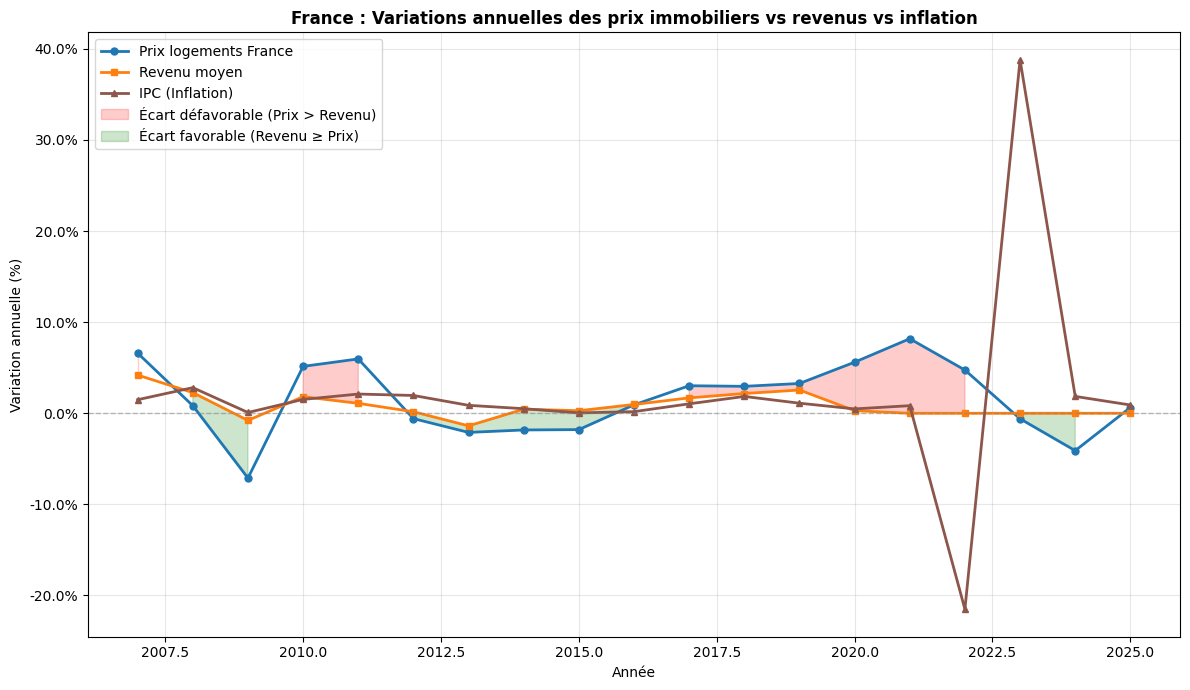


  --- Graphiques macro complémentaires ---
  📊 Génération G2 - Indices Prix France/Paris vs Loyers
Données détectées en base 1 (max=3.72), multiplication par 100


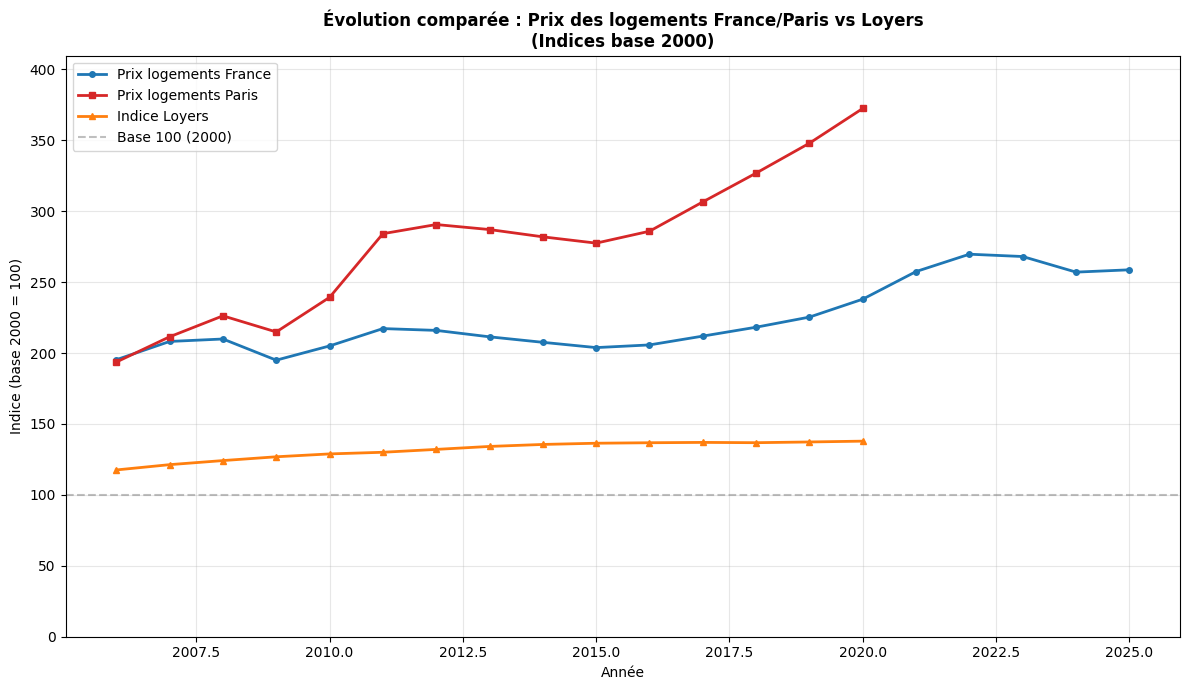

  📊 Génération G3 - Dette, Durée prêts, Transactions...


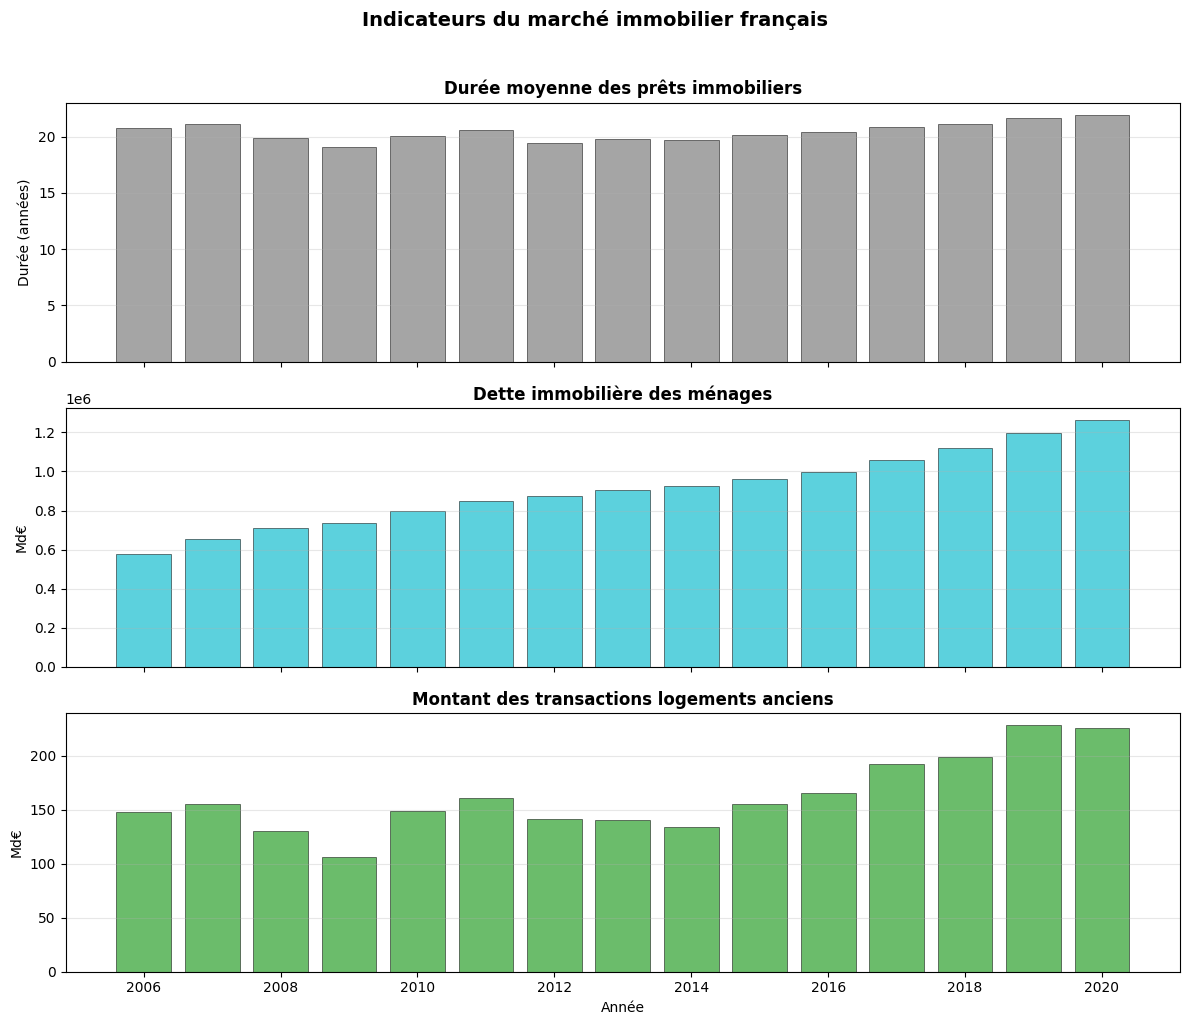

  📊 Génération G6 - Indicateurs d'accessibilité


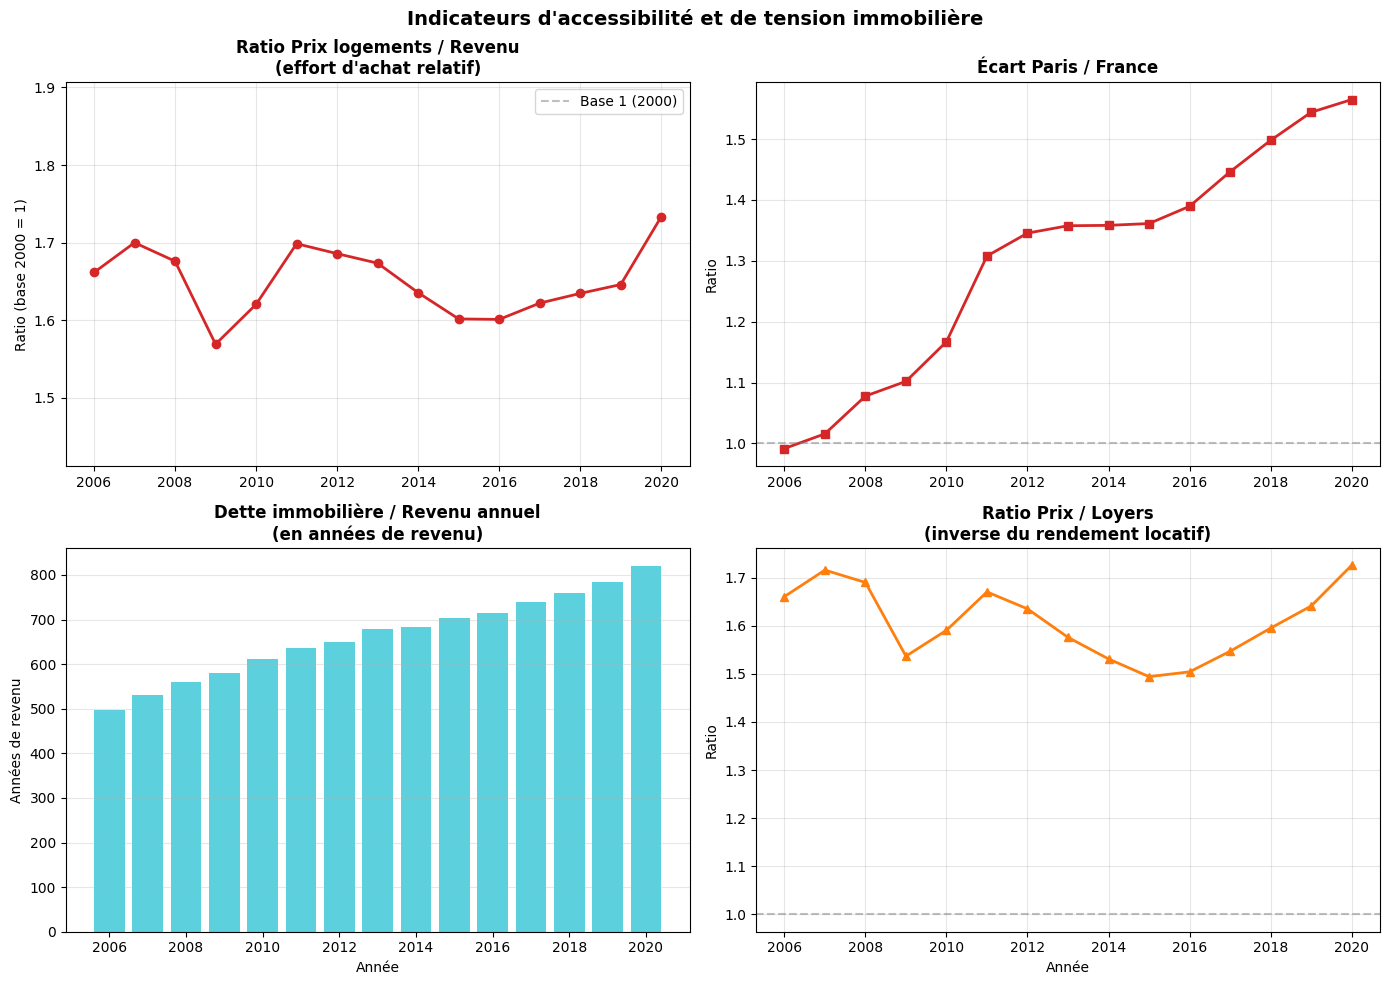


  --- Graphiques départementaux IdF ---
  📊 Génération G4 - Prix médian m² par département (barres)...


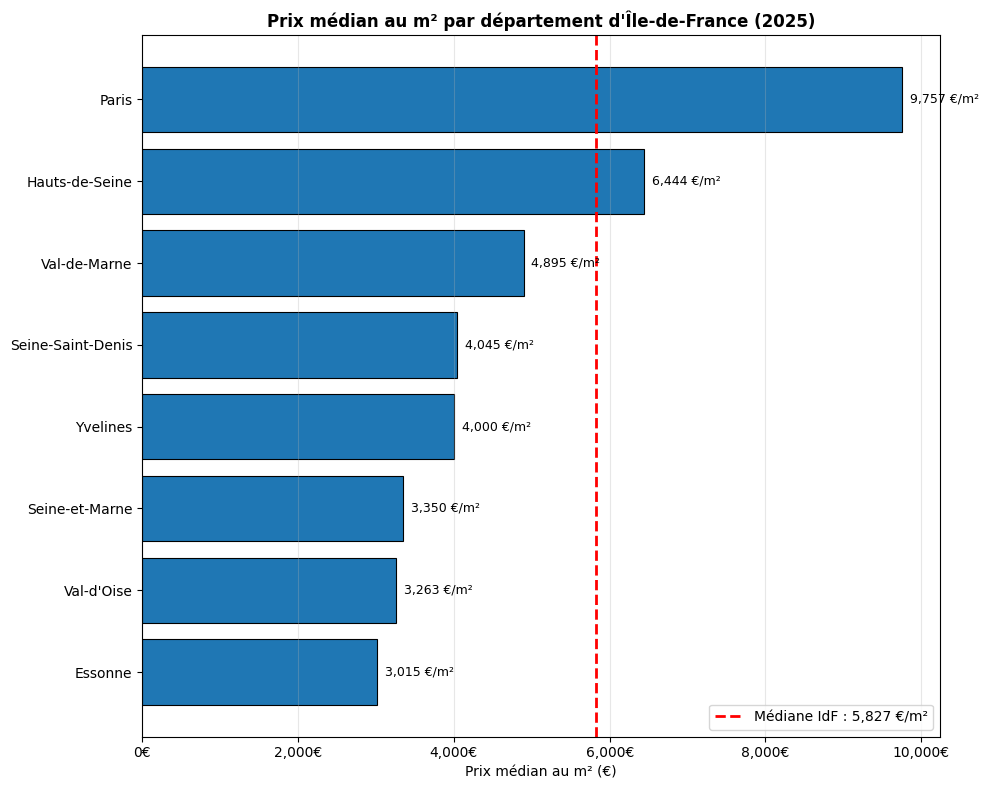

  📊 Génération G5 - Top 10 communes les plus chères...


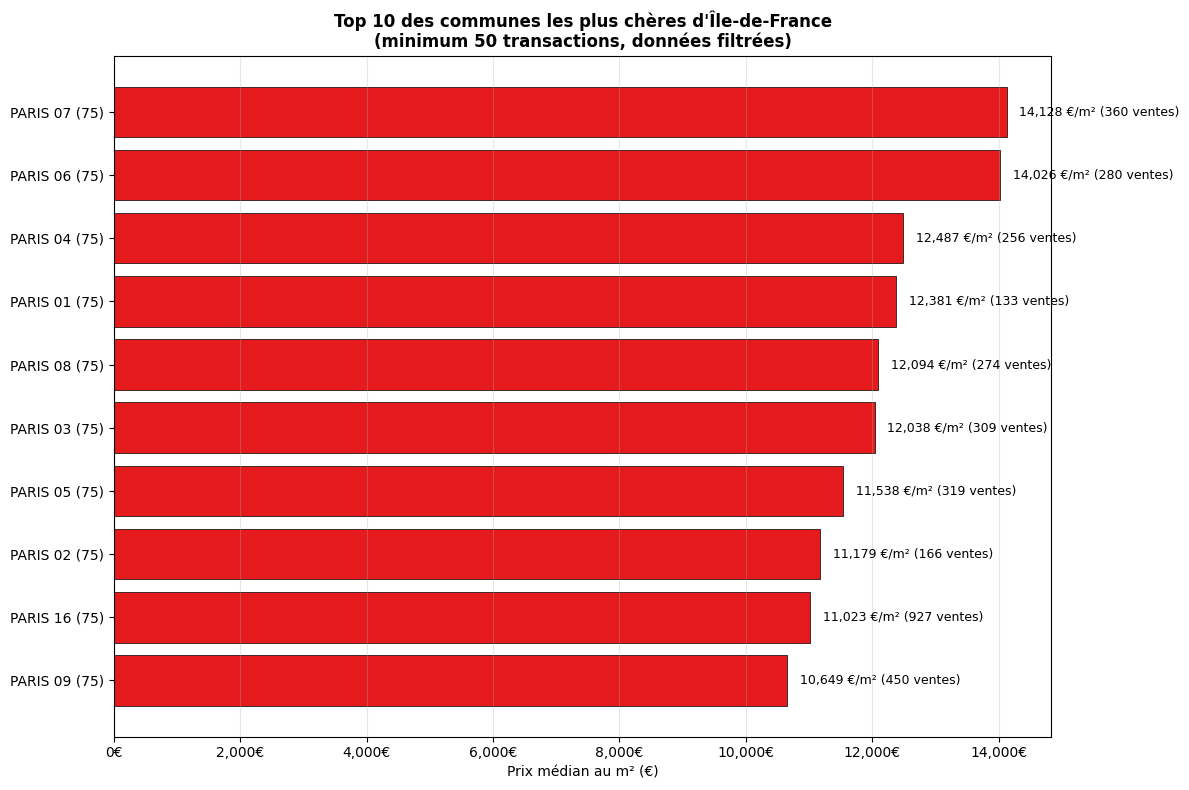



  RÉCAPITULATIF DES DATAFRAMES CRÉÉS

  DataFrame                                      Lignes     Colonnes
  ------------------------------------------------------------------
  df_taux_annuel                                     22            2
  df_macro                                           36           16
  df_macro_analyse                                   36           31
  df_macro_20                                        20           31
  df_dvf_brut                                 2,393,734           44
  df_dvf_idf                                    623,752           15
  df_dvf_analyse                                520,786           17
  df_agg_idf                                          6            5
  df_dvf_agg_5                                        5            5
  df_dvf_dept_10                                     48            6
  df_dvf_dept_last                                    8            6
  df_dvf_commune_last                               658        

In [7]:
# 5. MAIN : CRÉATION DES DATAFRAMES + GRAPHES
# ============================================================
def main():
    """
    Fonction principale : orchestration du pipeline complet.
    
    Flux de données :
    -----------------
    PARTIE A : Données nationales
        A.1 : Taux BdF → df_taux_annuel
        A.2 : Macro France → df_macro
    
    PARTIE B : Données DVF Île-de-France
        B.1 : DVF brut → df_dvf_brut
        B.2 : Filtre appartements → df_dvf_idf
    
    PARTIE C : Transformation & Agrégation
        C.1 : Analyse macro → df_macro_analyse, df_macro_20
        C.2 : Agrégats DVF → df_dvf_analyse, df_agg_idf, df_agg_5, etc.
        C.3 : Union Macro + DVF → df_union_macro_dvf
        C.4 : Global 5 ans → df_global_5 (utile pour vérifs, mais plus de graphiques dédiés)
    
    PARTIE D : Visualisations
        Graphiques utilisés dans la version finale :
        - G1 (France, variations % Prix/Revenu/IPC)
        - G2, G3 (macro France)
        - G4, G5 (DVF IdF)
        - G6 (France/IdF)
    """
    
    print("\n" + "=" * 100)
    print("  SCRIPT D'ANALYSE IMMOBILIÈRE")
    print("=" * 100)
    
    # ═══════════════════════════════════════════════════════════════
    # PARTIE A – Taux & Macro
    # ═══════════════════════════════════════════════════════════════
    afficher_section("PARTIE A – Taux & Macro", niveau=1)

    # A.1) Taux BdF
    df_taux_annuel = charger_taux_bdf(PATH_TAUX_BDF)

    # A.2) Macro France
    df_macro = charger_macro(PATH_GLOBAL, df_taux_annuel)

    # C.1) Macro – DataFrames d'analyse (enrichis avec nouveaux indicateurs)
    df_macro_analyse, df_macro_20 = construire_macro_analyse(df_macro)

    # ═══════════════════════════════════════════════════════════════
    # PARTIE B – DVF Île-de-France
    # ═══════════════════════════════════════════════════════════════
    afficher_section("PARTIE B – DVF Île-de-France", niveau=1)
    
    # B.1) DVF brut IdF
    df_dvf_brut = charger_dvf_idf(PATH_DVF_DIR)

    # B.2) DVF filtré : appartements vendus
    df_dvf_idf = filtrer_dvf_appartements(df_dvf_brut)

    # C.2) DVF – agrégats (filtrage des outliers)
    (
        df_dvf_analyse,
        df_agg_idf,
        df_dvf_agg_5,
        df_dvf_dept_10,
        df_dvf_dept_last,
        df_dvf_commune_last,
        df_top10_communes,
    ) = construire_dvf_agregats(df_dvf_idf)

    # ═══════════════════════════════════════════════════════════════
    # PARTIE C – Union & Consolidation
    # ═══════════════════════════════════════════════════════════════
    afficher_section("PARTIE C – Union & Consolidation", niveau=1)

    # C.3) DataFrame Union Macro + DVF
    df_union_macro_dvf = construire_df_union_macro_dvf(
        df_macro_analyse,
        df_dvf_analyse
    )

    # C.4) DataFrame global France + IdF (5 ans)
    df_global_5 = construire_df_global_5(df_macro_analyse, df_dvf_agg_5)

    # ═══════════════════════════════════════════════════════════════
    # PARTIE D – GRAPHIQUES
    # ═══════════════════════════════════════════════════════════════
    afficher_section("PARTIE D – GRAPHIQUES", niveau=1)

    # --- Graphes France (originaux) ---
    if not df_macro_20.empty:
        print("\n  --- Graphiques France ---")
        # G1 : Variations annuelles
        graphe_macro_prix_revenu_ipc(df_macro_20, OUTPUT_DIR)
    else:
        print("df_macro_20 vide : pas de graphes France originaux")

    # --- Graphes IdF globaux (G3 bis & G4 bis) ---
    if df_global_5.empty:
        print("df_global_5 vide : pas de df_global_5 (utilisé uniquement pour analyses, plus de graphes dédiés)")

    # --- Graphes IdF par département (évolution) ---
    if not df_macro_20.empty:
        print("\n  --- Graphiques macro complémentaires ---")
        # G2 : Indices Prix France/Paris vs Loyers
        graphe_indices_prix_loyers(df_macro_20, OUTPUT_DIR)

        # G3 : Dette immo, durée des prêts, montants de transactions
        graphe_dette_duree_transactions(df_macro_20, OUTPUT_DIR)

        # G6 : Indicateurs d'accessibilité
        graphe_accessibilite_immobiliere(df_macro_20, OUTPUT_DIR)

    if not df_dvf_dept_10.empty:
        print("\n  --- Graphiques départementaux IdF ---")
        # G4 : Prix médian m² par département (modifié : médian au lieu de moyen)
        graphe_prix_m2_par_dept_barre(df_agg_idf, df_dvf_dept_10, OUTPUT_DIR)

    else:
        print("df_dvf_dept_10 vide : pas de graphes départementaux")

    if not df_top10_communes.empty:
        # G5 : Top 10 communes les plus chères (inchangé)
        graphe_top10_communes(df_top10_communes, OUTPUT_DIR)
    else:
        print("df_top10_communes vide : pas de graphe Top 10")

    # ═══════════════════════════════════════════════════════════════
    # RÉCAPITULATIF FINAL
    # ═══════════════════════════════════════════════════════════════
    afficher_section("RÉCAPITULATIF DES DATAFRAMES CRÉÉS", niveau=1)
    
    dataframes_crees = {
        "df_taux_annuel": df_taux_annuel,
        "df_macro": df_macro,
        "df_macro_analyse": df_macro_analyse,
        "df_macro_20": df_macro_20,
        "df_dvf_brut": df_dvf_brut,
        "df_dvf_idf": df_dvf_idf,
        "df_dvf_analyse": df_dvf_analyse,
        "df_agg_idf": df_agg_idf,
        "df_dvf_agg_5": df_dvf_agg_5,
        "df_dvf_dept_10": df_dvf_dept_10,
        "df_dvf_dept_last": df_dvf_dept_last,
        "df_dvf_commune_last": df_dvf_commune_last,
        "df_top10_communes": df_top10_communes,
        "df_union_macro_dvf": df_union_macro_dvf,
        "df_global_5": df_global_5,
    }
    
    print("\n  {:40} {:>12} {:>12}".format("DataFrame", "Lignes", "Colonnes"))
    print("  " + "-" * 66)
    for nom, df in dataframes_crees.items():
        if not df.empty:
            print(f"  {nom:40} {df.shape[0]:>12,} {df.shape[1]:>12}")
        else:
            print(f"  {nom:40} {'(vide)':>12} {'-':>12}")
    
    # Liste des graphiques générés
    print("\n  GRAPHIQUES GÉNÉRÉS :")
    print("  " + "-" * 66)
    graphiques = [
        ("G1",  "France_Prix_Revenu_IPC",         "Variations annuelles Prix/Revenu/IPC"),
        ("G2",  "Indices_Prix_Loyers",            "Indices Prix France/Paris vs Loyers"),
        ("G3",  "Dette_Duree_Transactions",       "Dette, durée des prêts, transactions"),
        ("G4", "Prix_m2_Departements_Barres",    "Prix MÉDIAN m² par département"),
        ("G5", "Top10_Communes_Cheres",          "Top 10 communes (prix médian m²)"),
        ("G6", "Accessibilite_Immobiliere",      "Indicateurs d'accessibilité"),
    ]
    for code, fichier, description in graphiques:
        print(f"  • {code}_{fichier}.png : {description}")
    
    print("\n" + "=" * 100)
    print(" FIN DU SCRIPT ")
    print("=" * 100)
    
    # Retourner les DataFrames pour utilisation interactive
    return dataframes_crees


if __name__ == "__main__":
    resultats = main()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bernard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== Texte brut concaténé ===


Classements
Brandvoice
Magazine Forbes
Bibliothèque
Je m’abonne
Rechercher
Rechercher
Rechercher
Club Forbes
Business
Technologie
Entrepreneurs
Management
Finance
Environnement
Lifestyle
Luxe
Femmes@Forbes
Business, Finance, Société
Immobilier en Île-de-France, ce qu’il faut savoir avant d’investir
Immobilier en Île-de-France, ce qu'il faut savoir avant d'investir - penthouse suspendu dans le ciel de paris 75017 prix confidentiel
Immobilier en Île-de-France, ce qu'il faut savoir avant d'investir
Pierre Berthoux
Pierre Berthoux
08 septembre 2025
En 2025, l’immobilier en Île-de-France affiche des signes de reprise après deux années marquées par des incertitudes économiques. Forbes France vous propose un panorama des tendances du marché, avec des analyses d’experts et un focus sur les zones et les segments les plus porteurs.

Un article issu du numéro 31 – été 2025, de Forbes France

 

Après deux années d’instabilité économique et des fluctuations des taux 

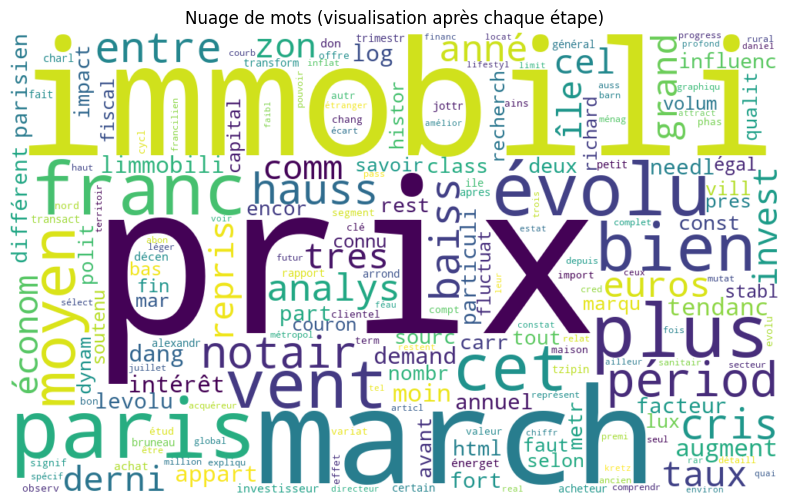

In [10]:
# -*- coding: utf-8 -*-
import os
import re
import subprocess
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from wordcloud import WordCloud

# Vérification et téléchargement des ressources NLTK
for resource in ("punkt", "stopwords"):
    try:
        nltk.data.find(f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource)

repertoire_textes = "INPUT/ARTICLES_PRESSE"
texte_brut = ""

for nom_fichier in os.listdir(repertoire_textes):
    chemin = os.path.join(repertoire_textes, nom_fichier)
    if not os.path.isfile(chemin):
        continue

    if nom_fichier.lower().endswith(".md"):
        try:
            result = subprocess.run(
                ["pandoc", chemin, "-t", "plain"],
                capture_output=True,
                text=True,
                check=True
            )
            contenu = result.stdout
        except Exception:
            with open(chemin, "r", encoding="utf-8") as f:
                contenu = f.read()
    else:
        with open(chemin, "r", encoding="utf-8") as f:
            contenu = f.read()

    texte_brut += contenu + " "

# Afficher le texte brut concaténé
print("=== Texte brut concaténé ===\n")
print(texte_brut)

# Passage en minuscules
texte = texte_brut.lower()
print("\n=== Après passage en minuscules ===\n")
print(texte)

# Suppression de la ponctuation, des chiffres et caractères non alphabétiques
texte = re.sub(r"[^a-zàâäéèêëïîôöùûüçœæ\s]", " ", texte)
texte = re.sub(r"\s+", " ", texte).strip()
print("\n=== Après nettoyage (ponctuation/chiffres) ===\n")
print(texte)

# Tokenisation
tokens = word_tokenize(texte, language="french")
print("\n=== Tokens (avant stopwords) ===\n")
print(tokens)

# Stopwords et mots indésirables
stopwords_fr = set(stopwords.words("french"))
mots_sale = {"forbes", "brandvoice", "newsletter", "service", "club", "logo"}
stopwords_fr.update(mots_sale)

tokens_filtrés = [mot for mot in tokens if mot not in stopwords_fr and len(mot) > 2]
print("\n=== Tokens (après suppression des stopwords et mots courts) ===\n")
print(tokens_filtrés)

# Racinisation
stemmer = FrenchStemmer()
tokens_stemmés = []
for mot in tokens_filtrés:
    try:
        tokens_stemmés.append(stemmer.stem(mot))
    except Exception:
        tokens_stemmés.append(mot)

# Suppression des racines trop courtes
tokens_stemmés = [mot for mot in tokens_stemmés if len(mot) > 2]
print("\n=== Tokens après racinisation ===\n")
print(tokens_stemmés)

# Reconstitution pour le nuage de mots
texte_final = " ".join(tokens_stemmés)

# Génération du nuage de mots
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="viridis",
    collocations=False
).generate(texte_final)

# Affichage
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots (visualisation après chaque étape)")
plt.show()